<a href="https://colab.research.google.com/github/Maagiio/NLP/blob/master/01_Perceptron_Test_lernen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Perceptron

## Perceptron
The perceptron is a fundamental building block of neural networks.  It's a simplified model of a biological neuron that takes multiple binary inputs, multiplies each by a weight, sums them up, and then applies an activation function to produce a single binary output.

**Key components of a perceptron:**

* **Inputs (x₁, x₂, ..., xₙ):**  These are the input signals to the perceptron, typically binary values (0 or 1).
* **Weights (w₁, w₂, ..., wₙ):** Each input has an associated weight representing its importance or influence on the output.  These weights are learned during the training process.
* **Bias (b):**  The bias acts as an offset, allowing the perceptron to activate even when all inputs are zero.  It's similar to the threshold in the tilting bucket model.  
* **Weighted sum (z):**  This is the sum of the products of inputs and their corresponding weights, plus the bias:  z = (w₁x₁ + w₂x₂ + ... + wₙxₙ) + b
* **Activation function (f(z)):** This function determines the perceptron's output based on the weighted sum.  A common activation function is the step function:
    * f(z) = 1 if z >= 0
    * f(z) = 0 otherwise


**Perceptron Learning Rule:**

The perceptron learning rule is an iterative algorithm used to adjust the weights and bias of a perceptron to correctly classify input data.  It works as follows:

1. **Initialization:** Initialize the weights and bias to small random values.

2. **Iteration:**  Repeat the following steps for each training example (input and its desired output):
    * Calculate the weighted sum (z).
    * Apply the activation function to get the output (ŷ).
    * Compare the predicted output (ŷ) with the desired output (y).
    * Update the weights and bias based on the error:
       * If the prediction is correct (ŷ = y), do nothing.
       * If the prediction is incorrect:
           * For each weight wᵢ:  wᵢ(new) = wᵢ(old) + η(y - ŷ)xᵢ
           * Bias update: b(new) = b(old) + η(y - ŷ)
           where η (learning rate) is a small positive constant that controls the step size of the weight adjustments.

3. **Convergence:** Repeat the iteration until the perceptron correctly classifies all training examples or a maximum number of iterations is reached.


The learning rule ensures that the weights are adjusted in the direction that reduces the classification error. The learning rate determines how quickly the weights converge to their optimal values.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


# Generate linearly separable data (example) - without seed
X = np.random.randn(100, 2)  # Data without seed
y = np.where(X[:, 0] + X[:, 1] > 0, 1, 0)  # Linear decision boundary


# Implementation of the Perceptron class with the following methods:
#     * __init__: Initializes the weights (randomly) and bias.
#     * predict: Predicts the class label for a given input vector.
#     * train: Implements the perceptron learning rule to update weights and bias based on the training data.

class Perceptron:
    def __init__(self, input_size, learning_rate=0.5):
        self.weights = np.random.rand(input_size)
        self.bias = 0
        self.learning_rate = learning_rate

    def predict(self, x):
        z = np.dot(self.weights, x) + self.bias
        return 1 if z >= 0 else 0

    def train(self, X, y, epochs=100):
      for _ in range(epochs):
        for i in range(len(X)):
          prediction = self.predict(X[i])
          if prediction != y[i]:
              self.weights += self.learning_rate * (y[i] - prediction) * X[i]
              self.bias += self.learning_rate * (y[i] - prediction)


### Task 1: Training and Visualization

Create an instance of the Perceptron class.
 Train the perceptron on the generated data using the train method. Visualize the decision boundary before and after training.  Use the plot_decision_boundary function below.


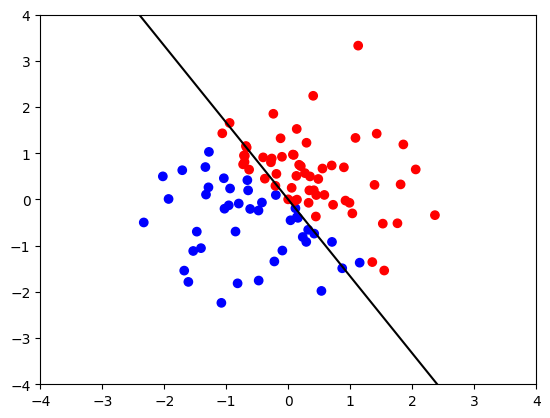

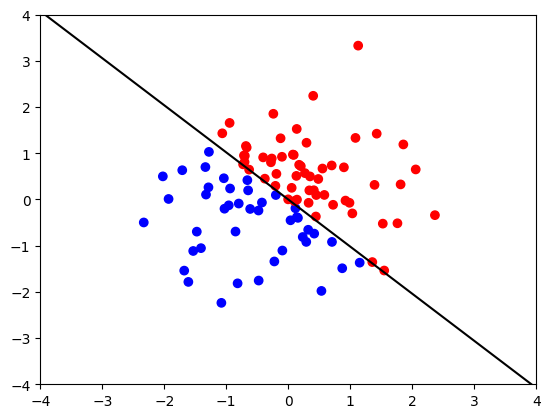

In [16]:
# Visualization function (provided)
def plot_decision_boundary(X, y, weights, bias):
    x1 = np.linspace(-4, 4, 100)
    x2 = -(weights[0] * x1 + bias) / weights[1]
    plt.plot(x1, x2, 'k-')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr')
    plt.xlim([-4, 4])
    plt.ylim([-4, 4])
    plt.show()

perceptron = Perceptron(2, learning_rate=10)
plot_decision_boundary(X, y, perceptron.weights, perceptron.bias)
perceptron.train(X, y, epochs = 3)
plot_decision_boundary(X, y, perceptron.weights, perceptron.bias)


### Task 2: Experimentation

1. Vary the learning rate and the number of training epochs.  Describe how these parameters affect the training process and the final decision boundary.

2. Generate a different dataset that is not linearly separable (e.g. using concentric circles).  What happens when you train the perceptron on this data?  Why?


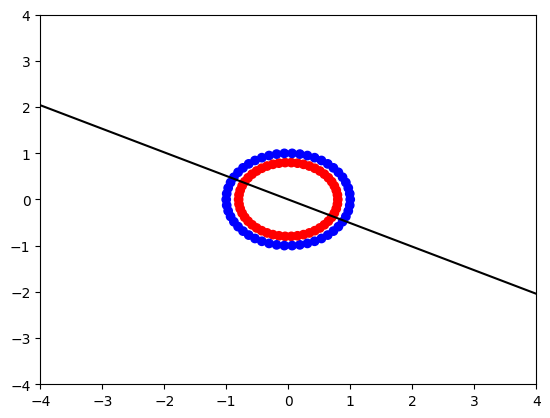

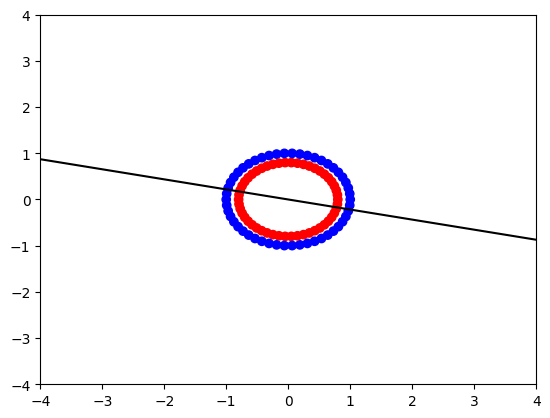

In [27]:
import sklearn
X, y = sklearn.datasets.make_circles()
perceptron = Perceptron(2, learning_rate=1)
plot_decision_boundary(X, y, perceptron.weights, perceptron.bias)
perceptron.train(X, y, epochs = 100)
plot_decision_boundary(X, y, perceptron.weights, perceptron.bias)

## Single-Layer NN with Basis Functions

In the previous exercise, you created a dataset that was not linearly separable and attempted to classify it using a simple neural network model. You likely observed that this single-layer neural network struggled to classify the data effectively. A simple neural network with only one layer and a linear decision boundary can only separate classes that are linearly separable. This means it can only classify data effectively if the classes can be divided by straight lines (or planes in higher dimensions). How can we make these models classify nonlinear data correctly?

**One Approach**: Derive Additional Features for Better Classification via Basis Functions

To improve our model’s performance, we can try creating new features that capture non-linear relationships between the existing features. By adding these features to our data, we can transform the dataset in ways that make it easier for a simple model to separate the classes.

### Task 3
You are allowed to create multiple new features, but you are restricted solely to simple comparisons and logical operations involving the original features. These comparisons will help you capture relationships between $X1$ and $X2$ that might aid in classification without directly using non-linear transformations like multiplication. Experiment by adding several features that capture different combinations of conditions. Integrate these new features into your dataset as additional columns. For example, you can use:
- Comparisons: Greater than (>) and less than (<)
- Logical Operators: AND (&) and OR (|)

Train the model **twice** on your extended dataset: once using `SigmoidActivationFunction()` and once using `LinearActivationFunction()`. Compare the learning curves (MSE over iterations) and the final test accuracy. Does the choice of activation function matter here? Why or why not?

### Task 4
Now, evaluate the impact of non-linear features of your choice. At least, try multiplications. After retraining, how does the model perform compared to Task 3? Is there a (set of) function(s) of $X1$ and $X2$ that allow for perfect classification?

Again, compare `SigmoidActivationFunction()` vs `LinearActivationFunction()` with your new features. Do the two activation functions behave differently than in Task 3? Discuss what you observe.


In [28]:
import numpy as np
from sklearn.metrics import mean_squared_error

class SigmoidActivationFunction:
    """
    A class implementing the sigmoid activation function and its derivative.
    """

    def __call__(self, x):
        """
        Calculate the sigmoid activation function for a given input x.

        Parameters:
        x : np.array or float
            The input value(s) to the sigmoid function.

        Returns:
        np.array or float
            The sigmoid function output for each element in x.
        """
        return 1 / (1 + np.exp(-x))

    def derivative(self, x):
        """
        Calculate the derivative of the sigmoid function for a given input x.

        Parameters:
        x : np.array or float
            The input value(s) to the sigmoid function.

        Returns:
        np.array or float
            The derivative of the sigmoid function for each element in x.
        """
        sigmoid_x = self.__call__(x)
        return sigmoid_x * (1 - sigmoid_x)


class LinearActivationFunction:
    """
    A class implementing the linear (identity) activation function and its derivative.
    """

    def __call__(self, x):
        """
        Calculate the linear activation function for a given input x.

        Parameters:
        x : np.array or float
            The input value(s).

        Returns:
        np.array or float
            The input unchanged.
        """
        return x

    def derivative(self, x):
        """
        Calculate the derivative of the linear function for a given input x.

        Parameters:
        x : np.array or float
            The input value(s).

        Returns:
        np.array or float
            Ones with the same shape as x.
        """
        return np.ones_like(x)


class NeuralNetwork:
    """
    A neural network model with a configurable number of layers, using gradient descent for optimization.
    """

    def __init__(self, input_dim, learning_rate=0.01, n_iterations=1000, activation_function=None):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        # Initialize weights as a list to allow multiple layers in the future
        self.weights = [np.random.rand(1, input_dim + 1) * 0.0001]  # Start with one layer's weights
        self.mse_history = []  # List to store MSE at each iteration
        self.activation_function = activation_function if activation_function is not None else SigmoidActivationFunction()

    def add_bias_column(self, X):
        """
        Add a bias column (of ones) to the input data.

        Parameters:
        X : np.array, shape (n_samples, input_dim)
            The input feature values.

        Returns:
        X_with_bias : np.array, shape (n_samples, input_dim + 1)
            The input with an added bias column.
        """
        X_with_bias = np.c_[np.ones(X.shape[0]), X]
        return X_with_bias

    def forward(self, X):
        """
        Perform the forward pass through the 0-th layer.

        Parameters:
        X : np.array, shape (n_samples, input_dim + 1)
            The input data with bias.

        Returns:
        layer_output : np.array
            Output of the final layer after applying the activation function.
        """
        layer_input = np.dot(X, self.weights[0].T)
        layer_output = self.activation_function(layer_input)
        return layer_output

    def predict(self, X):
        """
        Make predictions using the trained model with only the 0-th layer.
        """
        X_with_bias = self.add_bias_column(X)  # Add bias column
        return self.forward(X_with_bias)  # Forward pass through only the 0-th layer

    def fit(self, X, y):
        """
        Fit the model using gradient descent, adjusting weights iteratively.

        Parameters:
        X : np.array, shape (n_samples, input_dim)
            The input feature values.
        y : np.array, shape (n_samples,)
            The true target values.
        """
        y = y.reshape(-1, 1)  # Ensure y is a column vector (n_samples, 1)
        X_with_bias = self.add_bias_column(X)  # Add bias column to the input data

        for _ in range(self.n_iterations):
            # Forward pass through the 0-th layer
            layer_output = self.forward(X_with_bias)

            # Calculate Mean Squared Error and store it
            mse = mean_squared_error(y, layer_output)
            self.mse_history.append(mse)

            # Backward pass for the 0-th layer
            layer_input = np.dot(X_with_bias, self.weights[0].T)  # Linear combination
            delta = (layer_output - y) * self.activation_function.derivative(layer_input)
            gradient = np.dot(delta.T, X_with_bias) / X.shape[0]

            # Update weights by moving in the direction of the negative gradient
            self.weights[0] -= self.learning_rate * gradient

    def get_mse_history(self):
        """
        Get the history of MSE values during training.

        Returns:
        mse_history : list of float
            List containing the MSE at each iteration during training.
        """
        return self.mse_history


In [43]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Define custom centers for the dataset
centers = [(-2, 2), (-2, -2), (2, 2), (2, -2)]  # Four centers
cluster_std = 1.0  # Standard deviation for each cluster

# Generate synthetic dataset
X, y = make_blobs(n_samples=1000, centers=centers, cluster_std=cluster_std, random_state=42)

# Map clusters to two classes: 0 and 1
# Assign class 0 to clusters 0 and 1, and class 1 to clusters 2 and 3
y = (y == 1) | (y == 2)

# TODO Add n (as many as you like) features as additional columns
X = np.hstack((X, np.zeros((X.shape[0], 42))))
X[:, 2] = X[:, 0] > 0
X[:, 3] = X[:, 0] ** 2

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


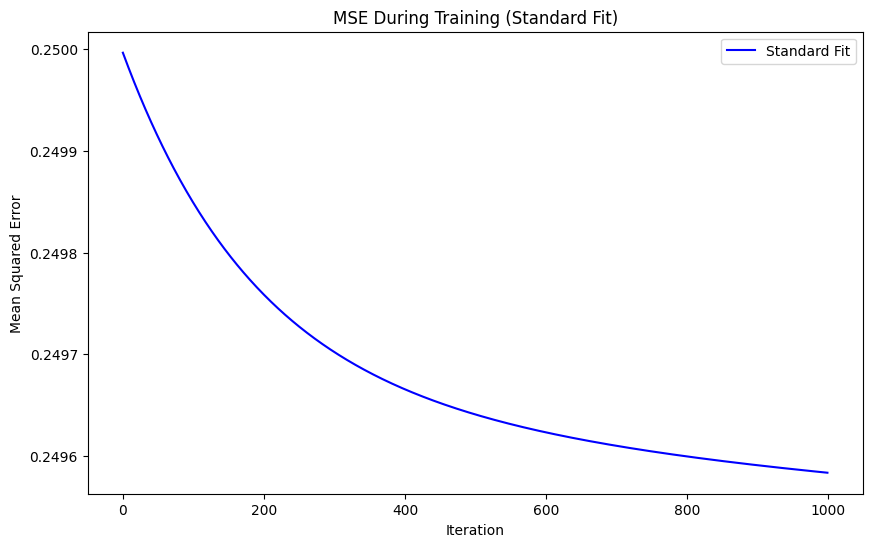

Accuracy on test set : 40.00%
Accuracy on train set: 49.62%


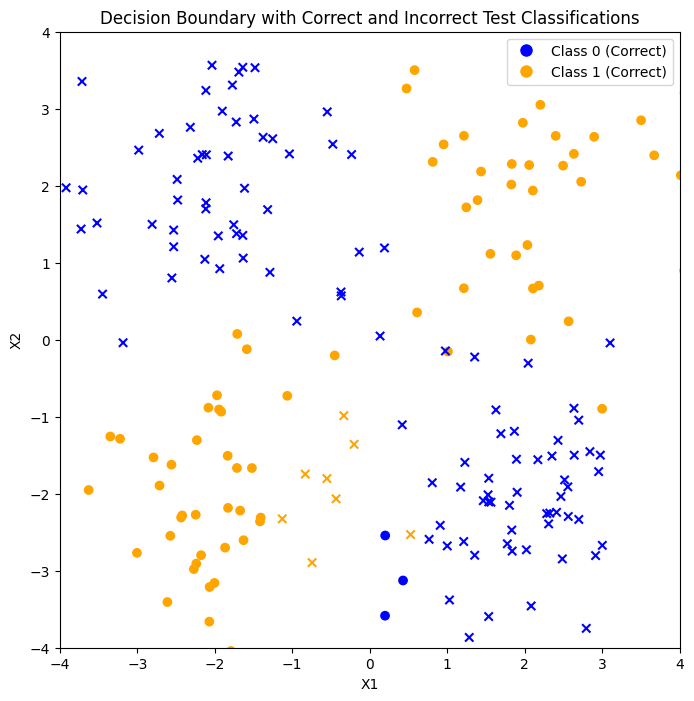

160
240


In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Initialize and train the NeuralNetwork model
input_dim = X_train.shape[1]
### TODO: Vary the iterations, learning rate and activation functions
model = NeuralNetwork(input_dim=input_dim, learning_rate=0.001, n_iterations=1000, activation_function=SigmoidActivationFunction())
model.fit(X_train, y_train)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(model.get_mse_history(), label="Standard Fit", color="blue")
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error")
plt.title("MSE During Training (Standard Fit)")
plt.legend()
plt.show()

# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_labels = (y_pred > 0.5).astype(int)  # Apply threshold to convert probabilities to binary labels

y_pred_train = model.predict(X_train)
y_pred_train_labels = (y_pred_train > 0.5).astype(int)  # Apply threshold to convert probabilities to binary labels

# Calculate accuracy for information
accuracy = accuracy_score(y_test, y_pred_labels)
accuracy_train = accuracy_score(y_train, y_pred_train_labels)
print(f"Accuracy on test set : {accuracy * 100:.2f}%")
print(f"Accuracy on train set: {accuracy_train * 100:.2f}%")

# Separate correctly and incorrectly classified points, keeping class colors
correct_x, correct_y, correct_colors = [], [], []
incorrect_x, incorrect_y, incorrect_colors = [], [], []

for i in range(len(y_test)):
    if y_pred_labels[i] == y_test[i]:  # Correct classification
        correct_x.append(X_test[i, 0])
        correct_y.append(X_test[i, 1])
        correct_colors.append('blue' if y_test[i] == 0 else 'orange')
    else:  # Incorrect classification
        incorrect_x.append(X_test[i, 0])
        incorrect_y.append(X_test[i, 1])
        incorrect_colors.append('blue' if y_test[i] == 0 else 'orange')

# Plot decision boundary and test data points
plt.figure(figsize=(8, 8))

# Plot correctly classified points (circles) and incorrectly classified points (crosses) with class color
plt.scatter(correct_x, correct_y, c=correct_colors, marker='o', label='Correctly Classified')
plt.scatter(incorrect_x, incorrect_y, c=incorrect_colors, marker='x', label='Incorrectly Classified')

# Adding legend for color and boundary
correct_class_label = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Class 0 (Correct)')
incorrect_class_label = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=10, label='Class 1 (Correct)')
plt.legend(handles=[correct_class_label, incorrect_class_label])

plt.xlim(-4,4)
plt.ylim(-4,4)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Decision Boundary with Correct and Incorrect Test Classifications")
plt.show()

print(len(correct_x) + len(correct_y))
print(len(incorrect_x) + len(incorrect_y))

The following 3D visualization shows the plane of separation nicely when exactly 3 features are present (so one more than the original feature). If the interactive visualization with widget does not work, run a cell containing `!pip install ipympl` and restart the kernel afterwards.

In [37]:
!pip install ipympl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 63.2 MB/s eta 0:00:00


In [38]:
%matplotlib widget
from mpl_toolkits.mplot3d import Axes3D

# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_labels = (y_pred > 0.5).astype(int)  # Apply threshold to convert probabilities to binary labels

# Calculate accuracy for reference
accuracy = accuracy_score(y_test, y_pred_labels)
print(f"Accuracy on test set: {accuracy * 100:.2f}%")

# Separate the test data into correctly and incorrectly classified points
correct_x, correct_y, correct_z, correct_colors = [], [], [], []
incorrect_x, incorrect_y, incorrect_z, incorrect_colors = [], [], [], []

for i in range(len(y_test)):
    if y_pred_labels[i] == y_test[i]:  # Correct classification
        correct_x.append(X_test[i, 0])
        correct_y.append(X_test[i, 1])
        correct_z.append(X_test[i, 2])  # Third engineered feature
        correct_colors.append('blue' if y_test[i] == 0 else 'orange')
    else:  # Incorrect classification
        incorrect_x.append(X_test[i, 0])
        incorrect_y.append(X_test[i, 1])
        incorrect_z.append(X_test[i, 2])  # Third engineered feature
        incorrect_colors.append('blue' if y_test[i] == 0 else 'orange')

# Plotting in 3D
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot correctly classified points as circles and incorrectly classified as crosses
ax.scatter(correct_x, correct_y, correct_z, c=correct_colors, marker='o', label='Correctly Classified')
ax.scatter(incorrect_x, incorrect_y, incorrect_z, c=incorrect_colors, marker='x', label='Incorrectly Classified')

# The decision boundary is where model output == 0.5 (classification threshold)
# For sigmoid: sigmoid(w·x) = 0.5 -> threshold w·x = 0
# For linear:  w·x = 0.5 -> threshold = 0.5
threshold = 0.5 if isinstance(model.activation_function, LinearActivationFunction) else 0.0

w0, w1, w2, *extra_weights = model.weights[0][0]  # Extract bias and weights
xx, yy = np.meshgrid(np.linspace(-4, 4, 50), np.linspace(-4, 4, 50))
zz = (threshold - w0 - w1 * xx - w2 * yy) / extra_weights[0]  # Calculate corresponding z values

# Plot the decision boundary plane
ax.plot_surface(xx, yy, zz, color='green', alpha=0.4, edgecolor='k', linewidth=0.5)

# Adding labels and legend
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("Engineered Feature")
ax.set_title("3D Decision Boundary with Correct and Incorrect Classifications")
ax.legend()

# Set a custom view angle to change perspective
ax.view_init(elev=5, azim=45)  # Adjust 'elev' and 'azim' for perspective

plt.show()

ValueError: Key backend: 'module://ipympl.backend_nbagg' is not a valid value for backend; supported values are ['gtk3agg', 'gtk3cairo', 'gtk4agg', 'gtk4cairo', 'macosx', 'nbagg', 'notebook', 'qtagg', 'qtcairo', 'qt5agg', 'qt5cairo', 'tkagg', 'tkcairo', 'webagg', 'wx', 'wxagg', 'wxcairo', 'agg', 'cairo', 'pdf', 'pgf', 'ps', 'svg', 'template', 'inline']

### Task 3 Answer
### Task 4 Answer

#### Feedback
To improve the exercises, we would be happy to hear your feedback. Please take 2min to fill out an [anonymous questionnaire](https://survey.mbp.tf.uni-bielefeld.de/index.php?r=survey/index&sid=285592).